In [25]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv

In [26]:
load_dotenv(override=True)

True

In [27]:


class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Feedback on the assistant's response")
    success_criteria_met: bool = Field(description="Whether the success criteria have been met")
    user_input_needed: bool = Field(description="True if more input is needed from the user, or clarifications, or the assistant is stuck")


In [28]:


class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    feedback_on_work: Optional[str]
    success_criteria_met: bool
    user_input_needed: bool

In [29]:


import nest_asyncio
nest_asyncio.apply()
async_browser =  create_async_playwright_browser(headless=False)  
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [30]:
from langchain_community.chat_models import ChatOllama

worker_llm = ChatOllama(
    model="llama3.1",
    base_url="http://localhost:11434"
)

evaluator_llm = ChatOllama(
    model="llama3.1",
    base_url="http://localhost:11434"
)

In [31]:
from langchain_community.chat_models import ChatOllama

llm = ChatOllama(
    model="llama3.1",
    base_url="http://localhost:11434"
)

print(llm.invoke("Hello"))

content='Hello! How are you today? Is there something I can help you with or would you like to chat?' additional_kwargs={} response_metadata={'model': 'llama3.1', 'created_at': '2026-06-05T18:01:42.488448Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 4221311875, 'load_duration': 2919786458, 'prompt_eval_count': 11, 'prompt_eval_duration': 223587333, 'eval_count': 23, 'eval_duration': 1071517586} id='run--019e98f2-a0d7-7c62-9787-62873d1e8acf-0'


In [32]:
def worker(state: State) -> Dict[str, Any]:
    system_message = f"""You are a helpful assistant that can use tools to complete tasks.
You keep working on a task until either you have a question or clarification for the user, or the success criteria is met.
This is the success criteria:
{state['success_criteria']}
You should reply either with a question for the user about this assignment, or with your final response.
If you have a question for the user, you need to reply by clearly stating your question. An example might be:

Question: please clarify whether you want a summary or a detailed answer

If you've finished, reply with the final answer, and don't ask a question; simply reply with the answer.
"""
    
    if state.get("feedback_on_work"):
        system_message += f"""
Previously you thought you completed the assignment, but your reply was rejected because the success criteria was not met.
Here is the feedback on why this was rejected:
{state['feedback_on_work']}
With this feedback, please continue the assignment, ensuring that you meet the success criteria or have a question for the user."""
    

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
    # Invoke the LLM with tools
    response = worker_llm.invoke(messages)
    
    # Return updated state
    return {
        "messages": [response],
    }

In [34]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Conversation history:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"User: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Tools use]"
            conversation += f"Assistant: {text}\n"
    return conversation

In [35]:
def evaluator(state: State):

    last_response = state["messages"][-1].content

    feedback_text = "Evaluation completed."

    success_met = True

    user_needed = False

    return {
        "messages": [
            AIMessage(content=f"Evaluator Feedback: {feedback_text}")
        ],
        "feedback_on_work": feedback_text,
        "success_criteria_met": success_met,
        "user_input_needed": user_needed
    }

In [36]:
def route_based_on_evaluation(state: State) -> str:
    if state["success_criteria_met"] or state["user_input_needed"]:
        return "END"
    else:
        return "worker"

In [ ]:
# Set up Graph Builder with State
graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node("worker", worker)
graph_builder.add_node("tools", ToolNode(tools=tools))
graph_builder.add_node("evaluator", evaluator)

# Add edges
graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
graph_builder.add_edge("tools", "worker")
graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
graph_builder.add_edge(START, "worker")

# Compile the graph
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

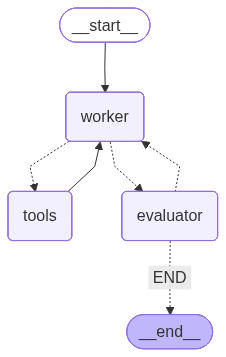

In [38]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
def make_thread_id() -> str:
    return str(uuid.uuid4())


async def process_message(message, success_criteria, history, thread):

    config = {"configurable": {"thread_id": thread}}

    state = {
        "messages": [
            HumanMessage(content=message)
        ],
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False
    }

    result = await graph.ainvoke(state, config=config)

    user = {"role": "user", "content": message}
    reply = {"role": "assistant", "content": result["messages"][-2].content}
    feedback = {"role": "assistant", "content": result["messages"][-1].content}

if history is None:
    history = []

return history + [user, reply, feedback]

async def reset():
    return "", "", None, make_thread_id()

In [47]:
result = await graph.ainvoke(
    {
        "messages": [HumanMessage(content="hello")],
        "success_criteria": "Say hello",
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False
    },
    config={
        "configurable": {
            "thread_id": "test-thread"
        }
    }
)

print(worker_llm.invoke("hello"))

content='Hello! How are you today? Is there something I can help you with or would you like to chat?' additional_kwargs={} response_metadata={'model': 'llama3.1', 'created_at': '2026-06-05T18:13:03.194098Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 1327635917, 'load_duration': 50030833, 'prompt_eval_count': 11, 'prompt_eval_duration': 199138709, 'eval_count': 23, 'eval_duration': 1071806375} id='run--019e98fd-0f28-7b21-9194-679ce7f809fc-0'


In [3]:
import gradio as gr

def echo(x):
    return x

demo = gr.Interface(
    fn=echo,
    inputs="text",
    outputs="text"
)

demo.launch(server_port=7899)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (/opt/homebrew/lib/python3.11/site-packages/huggingface_hub/__init__.py)

In [4]:
import gradio
import huggingface_hub

print(gradio.__version__)
print(huggingface_hub.__version__)

ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (/opt/homebrew/lib/python3.11/site-packages/huggingface_hub/__init__.py)

In [5]:
import gradio as gr

def echo(x):
    return x

with gr.Blocks() as demo:
    txt = gr.Textbox()
    out = gr.Textbox()
    txt.submit(echo, txt, out)

demo.launch(
    server_name="127.0.0.1",
    server_port=8001,
    show_api=False
)

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/uvicorn/protocols/http/h11_impl.py", line 415, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.11/site-packages/uvicorn/middleware/proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.11/site-packages/fastapi/applications.py", line 1159, in __call__
    response_model_include=response_model_include,
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.11/site-packages/starlette/applications.py", line 90, in __call__
  File "/opt/homebrew/lib/python3.11/site-packages/starlette/middleware/errors.py", line 186, in __call__
    # to optionally raise the error within the test case.
    ^^^^^^^^^
  File "/op

Running on local URL:  http://127.0.0.1:8001


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/uvicorn/protocols/http/h11_impl.py", line 415, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.11/site-packages/uvicorn/middleware/proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.11/site-packages/fastapi/applications.py", line 1159, in __call__
    response_model_include=response_model_include,
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.11/site-packages/starlette/applications.py", line 90, in __call__
  File "/opt/homebrew/lib/python3.11/site-packages/starlette/middleware/errors.py", line 186, in __call__
    # to optionally raise the error within the test case.
    ^^^^^^^^^
  File "/op

ValueError: When localhost is not accessible, a shareable link must be created. Please set share=True or check your proxy settings to allow access to localhost.